In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df = pd.read_csv('../data/cleaned_data/vgchartz-2024-cleaned.csv')
df['year'] = df['year'].astype(str).str[:4]

### Bar Graph of console total sales

In [75]:
df_total_sale = df.groupby(['console'])['total_sales'].sum()

df_total_sale.sort_values(ascending=False, inplace=True)

df_top_20 = df_total_sale[:20]

C:\Users\cciri\AppData\Local\Temp\ipykernel_228\3280878157.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=50)


[Text(0, 0, 'PS2'),
 Text(1, 0, 'X360'),
 Text(2, 0, 'PS3'),
 Text(3, 0, 'PS'),
 Text(4, 0, 'PS4'),
 Text(5, 0, 'Wii'),
 Text(6, 0, 'DS'),
 Text(7, 0, 'XOne'),
 Text(8, 0, 'PSP'),
 Text(9, 0, 'XB'),
 Text(10, 0, 'GBA'),
 Text(11, 0, 'PC'),
 Text(12, 0, 'GC'),
 Text(13, 0, '3DS'),
 Text(14, 0, 'N64'),
 Text(15, 0, '2600'),
 Text(16, 0, 'SNES'),
 Text(17, 0, 'PSV'),
 Text(18, 0, 'NES'),
 Text(19, 0, 'NS')]

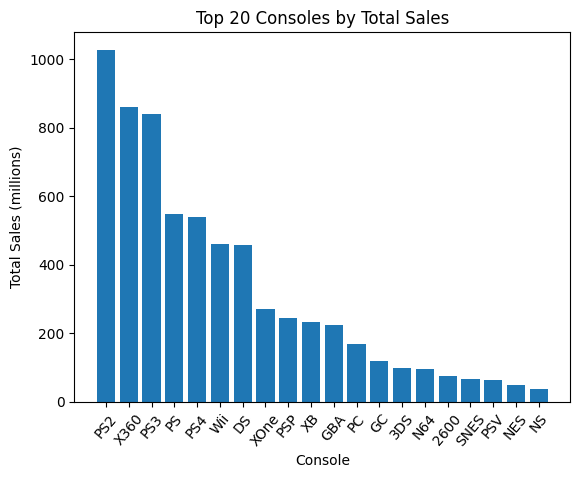

In [76]:
fig, ax = plt.subplots()

labels = df_top_20.index
ax.bar(df_top_20.index, df_top_20.values)
ax.set_title('Top 20 Consoles by Total Sales')
ax.set_xlabel('Console')
ax.set_ylabel('Total Sales (millions)')
ax.set_xticklabels(labels, rotation=50)


### Sales Per Year Per Console

In [77]:
df_total_sale_by_console_and_date = df.groupby(['console', 'year'])['total_sales'].sum()

df_total_sale_by_console_and_date.sort_values(ascending=False, inplace=True)
df_total_sale_by_console_and_date.head(20)

console  year
PS2      2002    176.94
         2003    165.68
PS3      2011    155.48
PS2      2004    151.58
X360     2011    142.51
         2010    140.63
PS2      2005    135.93
PS       1999    129.67
PS3      2010    121.99
X360     2008    121.29
PS2      2001    116.85
DS       2008    113.40
PS4      2016    112.96
         2015    111.69
         2017    109.23
X360     2009    108.71
PS3      2009    107.79
Wii      2009    107.39
PS       2000    106.04
PS3      2012    105.29
Name: total_sales, dtype: float64

(array([790.,  37.,  17.,  12.,  10.,   7.,   5.,   5.,   5.,   3.,   4.,
          1.,   3.,   3.,   2.,   2.,   4.,   4.,   5.,   3.,   2.,   1.,
          0.,   2.,   1.,   1.,   1.,   0.,   1.,   1.]),
 array([  0.   ,   5.898,  11.796,  17.694,  23.592,  29.49 ,  35.388,
         41.286,  47.184,  53.082,  58.98 ,  64.878,  70.776,  76.674,
         82.572,  88.47 ,  94.368, 100.266, 106.164, 112.062, 117.96 ,
        123.858, 129.756, 135.654, 141.552, 147.45 , 153.348, 159.246,
        165.144, 171.042, 176.94 ]),
 <BarContainer object of 30 artists>)

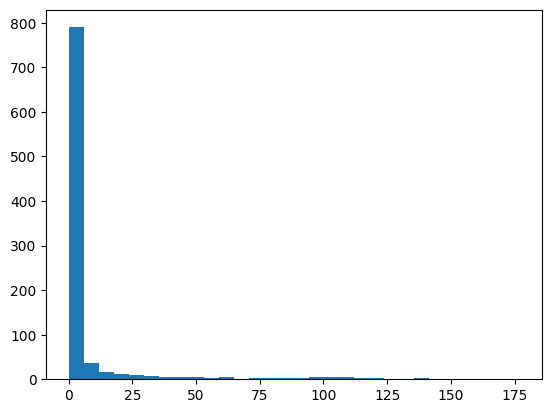

In [78]:
fig, ax = plt.subplots()

ax.hist(df_total_sale_by_console_and_date, bins=30, stacked=True)

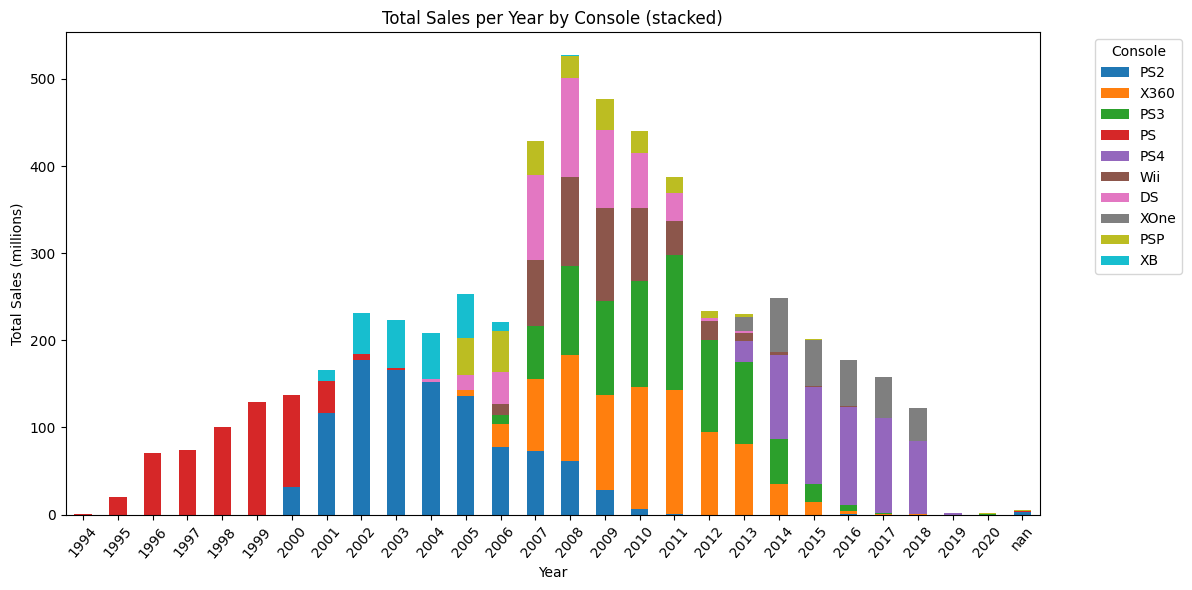

In [79]:
# Pivot to have years as index and consoles as columns (fill missing with 0)
df_year_console = df.groupby(['year','console'])['total_sales'].sum().unstack(fill_value=0)
# Option: limit to top 10 consoles by overall total sales to keep the chart readable
top_consoles = df.groupby('console')['total_sales'].sum().nlargest(10).index
df_year_console_top = df_year_console[top_consoles]
# Remove years with zero total sales across all selected consoles
df_year_console_top = df_year_console_top.loc[df_year_console_top.sum(axis=1) > 0]
labels = df_year_console_top.index 

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12,6))
df_year_console_top.plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Year') 
ax.set_xticklabels(labels, rotation=50)
ax.set_ylabel('Total Sales (millions)')
ax.set_title('Total Sales per Year by Console (stacked)')
ax.legend(title='Console', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()